In [3]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import re
from collections import Counter
import pandas as pd




## Question 1

In [6]:


# the meat

def run_simulations(num_simulations=100, sequence_length=10**6, lambda_value=0.1):
#def run_simulations(num_simulations=50, sequence_length=10**7, lambda_value=0.1): # the quicker one
    
    # store everything
    all_simulation_counts = []

    # a single simlulation
    for _ in range(num_simulations):
        
        # professor dodds approach with the list method
        sequence = [1]
        max_value = 1 # the current number we are at, so we can keep moving forward
        
        for _ in range(sequence_length):
            flip = random.random()
            if flip < lambda_value:
                
                #create a new group and add it
                max_value += 1
                sequence.append(max_value) 
            else:
                
                # randomly choose an existing element and add it 
                sequence.append(random.choice(sequence))
        
        # get the total number of intsances of each number. That is, group is the number and this gets us the number in each group
        number_counts = pd.Series(sequence).value_counts().sort_index()
        
        # add to the master simulation list
        all_simulation_counts.append(number_counts)

   
    
    # looking over all the simulations, get the average of each count for the groups. 
    average_counts_df = pd.concat(all_simulation_counts, axis=1).fillna(0).mean(axis=1).reset_index()  # convert it all to dataframes so we can plot
    average_counts_df.columns = ['Number', 'Average Count']
    
    # add the rank 
    average_counts_df["rank"]=average_counts_df['Number'].rank(method='average', ascending=True)
    
    return average_counts_df



# plotting 
def plot_results(lambda_values):
    
    # create the subplots
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # title
    fig.suptitle('Rank vs Average Count for Different Lambda Values (Log-Log Plot)', fontsize=16)

    # loop over lambda values
    for i, lambda_value in enumerate(lambda_values):
        results_df = run_simulations(lambda_value=lambda_value) # run the simulation for said lambda
        display(results_df)
        x = np.log10(results_df['rank'])
        y = np.log10(results_df['Average Count'])
        
        axes[i].scatter(x, y, label='Data Points')
        
        # get slope
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        
        # plot line of best fit
        best_fit_line = slope * x + intercept
        axes[i].plot(x, best_fit_line, color='red', label=f'Best Fit Line (slope={slope:.4f})')
        
        # labels
        axes[i].set_title(f'Lambda = {lambda_value}')
        axes[i].set_xlabel('log(Rank)')
        axes[i].set_ylabel('log(Average Count)')
        axes[i].legend()
        plt.grid(True)
        

    # formatting
    plt.tight_layout()
    plt.show()




lambda_values = [0.1, 0.01, 0.001] #lambda aka rho


#lambda_values = [0.001]
# plot ie call everything
plot_results(lambda_values)


# i think the point is the 


,Number,Average Count,rank
0,1,250532.78,1.0
1,2,57330.53,2.0
2,3,26734.63,3.0
3,4,13153.96,4.0
4,5,12198.25,5.0
...,...,...,...
100718,100719,0.01,100719.0
100719,100720,0.01,100720.0
100720,100721,0.01,100721.0
100721,100722,0.01,100722.0


## Question 4

/var/folders/ln/5vd2y_gn2_g8qft7kqsyrp4m0000gn/T/ipykernel_61166/4029890998.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['percentage'] = (df_unique['number of times each count appears'] / total) * 100


,Word,Count,number of times each count appears,percentage
2,035,1,17738,56.494044
9,10th,2,4887,15.564686
54,1885,3,2241,7.137397
6,1000,4,1282,4.083063
5,100,5,918,2.923753
...,...,...,...,...
28248,to,4955,1,0.003185
191,a,6500,1,0.003185
1035,and,7197,1,0.003185
19298,of,8115,1,0.003185


the number of unique words is: 31398 and the total number of words is:  264706


,Word,Count,number of times each count appears,percentage,rank,rank log,freq log
2,035,1,17738,56.494044,1.0,0.000000,4.248905
9,10th,2,4887,15.564686,2.0,0.301030,3.689042
54,1885,3,2241,7.137397,3.0,0.477121,3.350442
6,1000,4,1282,4.083063,4.0,0.602060,3.107888
5,100,5,918,2.923753,5.0,0.698970,2.962843
...,...,...,...,...,...,...,...
28248,to,4955,1,0.003185,291.0,2.463893,0.000000
191,a,6500,1,0.003185,292.0,2.465383,0.000000
1035,and,7197,1,0.003185,293.0,2.466868,0.000000
19298,of,8115,1,0.003185,294.0,2.468347,0.000000


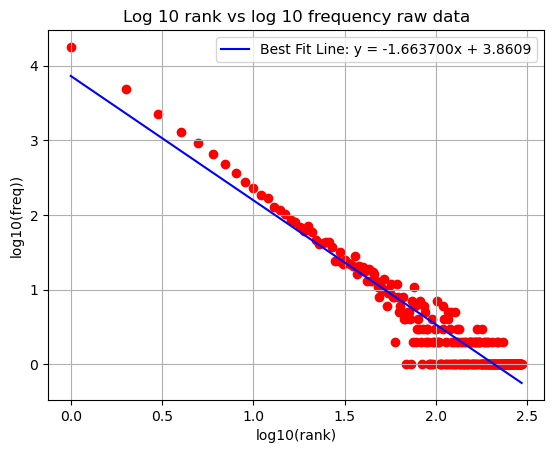

In [3]:


# differences are probably do to cleaning


file_path = "/Users/dannysatterthwaite/Desktop/School-UVM/Fall Senior/CS-2100/pocs-6-4.rtf" # unflitered

with open(file_path, 'r') as file:
    content = file.read()

# Now splitting based on ":" and processing the data into a DataFrame
data = [line.split(':') for line in content.strip().split('\n') if ':' in line]
df = pd.DataFrame(data, columns=["Word", "Count"])


#cleaning
df['Word'] = df['Word'].str.replace(r'\\', '', regex=True)
df['Count'] = df['Count'].str.replace(r'\\', '', regex=True)
df['Count'] = df['Count'].str.replace(r'[^\d]', '', regex=True)

#convert to int
df["Count"]=df["Count"].astype(int)


#aggregating
df['number of times each count appears'] = df.groupby('Count')['Count'].transform('count')

#drop duplicates so it doesnt duobule count
df_unique = df.drop_duplicates(subset='Count')

# get the percentage for each "umber of times each count appears

total = df_unique['number of times each count appears'].sum()
df_unique['percentage'] = (df_unique['number of times each count appears'] / total) * 100


df_unique=df_unique.sort_values(by="Count", ascending=True)

# results
display(df_unique)


# doing some googling these numbers make sense. not exact but certainly in the ball park
print("the number of unique words is:", df_unique["number of times each count appears"].sum(), "and the total number of words is: ", df["Count"].sum() )


# think that's good

# plotting. THis is much better


df_unique['rank']=df_unique['Count'].rank(method='average', ascending=True)

df_unique["rank log"]=np.log10(df_unique['rank'])

df_unique['freq log']=np.log10(df_unique['number of times each count appears'])

display(df_unique)


plt.scatter(df_unique['rank log'], df_unique['freq log'], marker='o', color='r')
slope, intercept = np.polyfit(df_unique['rank log'], df_unique['freq log'], 1)
x_fit = df_unique['rank log']
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color='b', label=f'Best Fit Line: y = {slope:.6f}x + {intercept:.4f}')
plt.title('Log 10 rank vs log 10 frequency raw data')
plt.xlabel('log10(rank)')
plt.ylabel('log10(freq))')
plt.grid(True)
plt.legend()

# much better

# so 1.663=1-.115? is that right no 


In [4]:
# theoretical calculations

#p ie the rate
p=0.115


# total number
t=31398

n_1_g=(1/(1-p))*t

n_2_g=((1-p)/((3-2*p)*(2-p)))*t

n_3_g=(((1-p)*(2-2*p))/((3-2*p)*(2-p)*(4-3*p)))*t

print(n_1_g, n_2_g, n_3_g)


35477.96610169492 5321.745875187927 2577.1519012537983


## Question 5

/var/folders/ln/5vd2y_gn2_g8qft7kqsyrp4m0000gn/T/ipykernel_61166/1576253446.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pp_unique['percentage'] = (df_pp_unique['number of times each count appears'] / total) * 100


,Word,Count,number of times each count appears
34,the,4322,1
68,to,4123,1
24,of,3619,1
92,and,3517,1
204,her,2211,1
...,...,...,...
4260,fearnot,1,3010
4261,indifferentbut,1,3010
4263,destructive,1,3010
4265,stability,1,3010


,Word,Count,number of times each count appears,percentage
6628,latest,1,3010,43.160310
4990,exasperate,2,937,13.435618
3266,consistent,3,623,8.933180
4102,thanking,4,366,5.248064
2127,progress,5,250,3.584743
...,...,...,...,...
204,her,2211,1,0.014339
92,and,3517,1,0.014339
24,of,3619,1,0.014339
68,to,4123,1,0.014339


the number of unique words is: 6974 and the total number of words is:  121776
The p ie rho value is  0.05726908422020759
129173.65704430237 20479.59994751526 10086.614383114951


,Word,Count,number of times each count appears,percentage,rank,rank log,freq log
6628,latest,1,3010,43.160310,1.0,0.000000,3.478566
4990,exasperate,2,937,13.435618,2.0,0.301030,2.971740
3266,consistent,3,623,8.933180,3.0,0.477121,2.794488
4102,thanking,4,366,5.248064,4.0,0.602060,2.563481
2127,progress,5,250,3.584743,5.0,0.698970,2.397940
...,...,...,...,...,...,...,...
204,her,2211,1,0.014339,227.0,2.356026,0.000000
92,and,3517,1,0.014339,228.0,2.357935,0.000000
24,of,3619,1,0.014339,229.0,2.359835,0.000000
68,to,4123,1,0.014339,230.0,2.361728,0.000000


6974

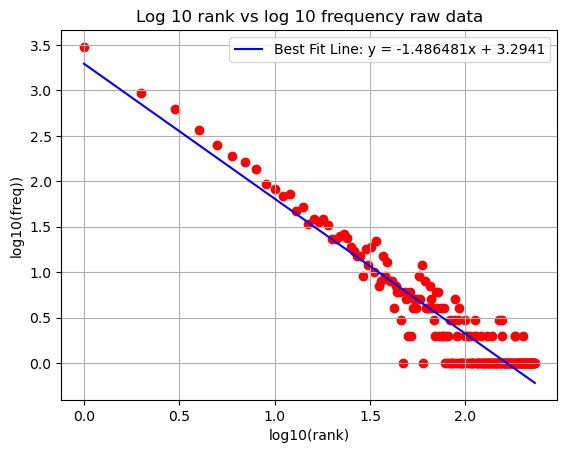

In [5]:
# pride and pred

# read it in
with open('/Users/dannysatterthwaite/Downloads/pride and pred pocs hw 6-5.rtf', 'r') as file:
    raw_text = file.read()


# strip all the bad characters and new line characters.
cleaned_text = re.sub(r'[^a-zA-Z\s]', '', raw_text)
cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
words = cleaned_text.lower().split()


# count each occurence of each word and display the result as a dataframe where the first column is eachw ord and the second is each words count

word_counts = Counter(words)
pp_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Count'])
pp_df = pp_df.sort_values(by='Count', ascending=False)

#pp_df.to_csv("pride_pred_tester.csv") # could enough, a handful double words but looks pretty damn good

#display(pp_df)

# now we are in the same spot as question 4

pp_df["Count"]=pp_df["Count"].astype(int)
pp_df['number of times each count appears'] = pp_df.groupby('Count')['Count'].transform('count')
df_pp_unique = pp_df.drop_duplicates(subset='Count')

total = df_pp_unique['number of times each count appears'].sum()
df_pp_unique['percentage'] = (df_pp_unique['number of times each count appears'] / total) * 100
df_pp_unique=df_pp_unique.sort_values(by="Count", ascending=True)

display(pp_df)
display(df_pp_unique)


# doing some googling these numbers make sense. not exact but certainly in the ball park
print("the number of unique words is:", df_pp_unique["number of times each count appears"].sum(), "and the total number of words is: ", pp_df["Count"].sum() )


#theoretical comparison goes here. do we use 0.115 again?
t=pp_df["Count"].sum()

#per simon# unique words/# all words like simon says in the slides in which case
p=df_pp_unique["number of times each count appears"].sum()/pp_df["Count"].sum()
print("The p ie rho value is ", p) #This is tiny about 1/3 of that for ulysses so the estiamges get all screwed up below it seams

n_1_g=(1/(1-p))*t
n_2_g=((1-p)/((3-2*p)*(2-p)))*t
n_3_g=(((1-p)*(2-2*p))/((3-2*p)*(2-p)*(4-3*p)))*t

# They are way off
print(n_1_g, n_2_g, n_3_g)




# lets do some graphing



# so we have the following, by zipf, rank vs freq gives us alpha, and per the slides, alpa=1-rho ie p. lets see

df_pp_unique['rank']=df_pp_unique['Count'].rank(method='average', ascending=True)

df_pp_unique["rank log"]=np.log10(df_pp_unique['rank'])

df_pp_unique['freq log']=np.log10(df_pp_unique['number of times each count appears'])

display(df_pp_unique)


plt.scatter(df_pp_unique['rank log'], df_pp_unique['freq log'], marker='o', color='r')
slope, intercept = np.polyfit(df_pp_unique['rank log'], df_pp_unique['freq log'], 1)
x_fit = df_pp_unique['rank log']
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color='b', label=f'Best Fit Line: y = {slope:.6f}x + {intercept:.4f}')
plt.title('Log 10 rank vs log 10 frequency raw data')
plt.xlabel('log10(rank)')
plt.ylabel('log10(freq))')
plt.grid(True)
plt.legend()

df_pp_unique['number of times each count appears'].sum()




/var/folders/ln/5vd2y_gn2_g8qft7kqsyrp4m0000gn/T/ipykernel_61166/3156148390.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lecomnte_unique['percentage'] = (df_lecomnte_unique['number of times each count appears'] / total) * 100


,Word,Count,number of times each count appears
17,de,3.0,623.0
13,le,1504.0,1.0
26,et,39.0,13.0
15,la,1924.0,1.0
61,e,56.0,5.0
...,...,...,...
6992,servira,NaN,NaN
6991,envisage,NaN,NaN
6988,mourirbb,NaN,NaN
6987,racontees,NaN,NaN


,Word,Count,number of times each count appears,percentage
353,bien,1.0,3010.0,43.160310
382,pas,2.0,937.0,13.435618
17,de,3.0,623.0,8.933180
235,monsieur,4.0,366.0,5.248064
119,se,5.0,250.0,3.584743
...,...,...,...,...
92,volcanique,3517.0,1.0,0.014339
24,smyrne,3619.0,1.0,0.014339
68,quand,4123.0,1.0,0.014339
34,aussitft,4322.0,1.0,0.014339


the number of unique words is: 6974.0 and the total number of words is:  121776.0
The p ie rho value is  0.05726908422020759
129173.65704430237 20479.59994751526 10086.614383114951


,Word,Count,number of times each count appears,percentage,rank,rank log,freq log
353,bien,1.0,3010.0,43.160310,1.0,0.000000,3.478566
382,pas,2.0,937.0,13.435618,2.0,0.301030,2.971740
17,de,3.0,623.0,8.933180,3.0,0.477121,2.794488
235,monsieur,4.0,366.0,5.248064,4.0,0.602060,2.563481
119,se,5.0,250.0,3.584743,5.0,0.698970,2.397940
...,...,...,...,...,...,...,...
92,volcanique,3517.0,1.0,0.014339,228.0,2.357935,0.000000
24,smyrne,3619.0,1.0,0.014339,229.0,2.359835,0.000000
68,quand,4123.0,1.0,0.014339,230.0,2.361728,0.000000
34,aussitft,4322.0,1.0,0.014339,231.0,2.363612,0.000000


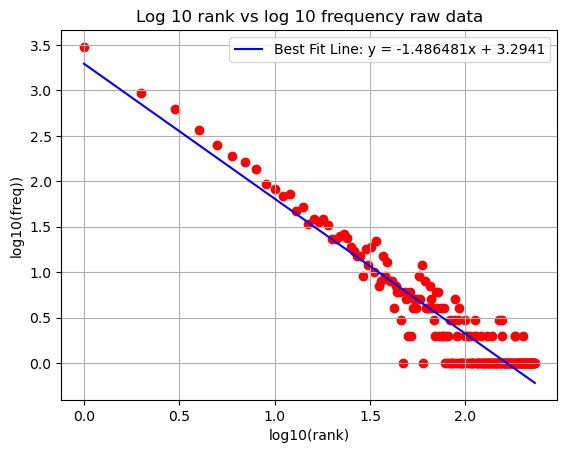

In [6]:
# the french one


# read it in
with open('/Users/dannysatterthwaite/Downloads/lecomnte - pocs - hw-6-5.rtf', 'r') as file:
    raw_text = file.read()



# strip all the bad characters and new line characters.
cleaned_text = re.sub(r'[^a-zA-Z\s]', '', raw_text)
cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()
words = cleaned_text.lower().split()


# count each occurence of each word and display the result as a dataframe where the first column is eachw ord and the second is each words count

word_counts = Counter(words)
df_lecomnte = pd.DataFrame(word_counts.items(), columns=['Word', 'Count'])
df_lecomnte = df_lecomnte.sort_values(by='Count', ascending=False)

df_lecomnte.to_csv("lecomnte_tester.csv") # could enough, a handful double words but looks pretty damn good

#display(pp_df)

# now we are in the same spot as question 4

df_lecomnte["Count"]=pp_df["Count"].astype(int)
df_lecomnte['number of times each count appears'] = df_lecomnte.groupby('Count')['Count'].transform('count')
df_lecomnte_unique = df_lecomnte.drop_duplicates(subset='Count')

total = df_lecomnte_unique['number of times each count appears'].sum()
df_lecomnte_unique['percentage'] = (df_lecomnte_unique['number of times each count appears'] / total) * 100
df_lecomnte_unique=df_lecomnte_unique.sort_values(by="Count", ascending=True)

display(df_lecomnte)
display(df_lecomnte_unique)


# Thus number is way off. i think its because appostrophied words in french are two words. thats according to google but the code seams right

print("the number of unique words is:", df_lecomnte_unique["number of times each count appears"].sum(), "and the total number of words is: ", df_lecomnte["Count"].sum() )


#theoretical comparison goes here. do we use 0.115 again?
t=df_lecomnte["Count"].sum()

#per simon# unique words/# all words like simon says in the slides in which case
p=df_lecomnte_unique["number of times each count appears"].sum()/df_lecomnte["Count"].sum()
print("The p ie rho value is ", p) #This is tiny about 1/3 of that for ulysses so the estiamges get all screwed up below it seams


n_1_g=(1/(1-p))*t
n_2_g=((1-p)/((3-2*p)*(2-p)))*t
n_3_g=(((1-p)*(2-2*p))/((3-2*p)*(2-p)*(4-3*p)))*t

# They are way off. same problem as PP so hmmmmm
print(n_1_g, n_2_g, n_3_g)






# so we have the following, by zipf, rank vs freq gives us alpha, and per the slides, alpa=1-rho ie p. lets see

df_lecomnte_unique['rank']=df_lecomnte_unique['Count'].rank(method='average', ascending=True)

df_lecomnte_unique["rank log"]=np.log10(df_lecomnte_unique['rank'])

df_lecomnte_unique['freq log']=np.log10(df_lecomnte_unique['number of times each count appears'])

display(df_lecomnte_unique)

df_lecomnte_unique = df_lecomnte_unique.dropna(subset='Count')
df_lecomnte_unique.to_csv('rankleoconte.csv')


plt.scatter(df_lecomnte_unique['rank log'], df_lecomnte_unique['freq log'], marker='o', color='r')
slope, intercept = np.polyfit(df_lecomnte_unique['rank log'], df_lecomnte_unique['freq log'], 1)
x_fit = df_lecomnte_unique['rank log']
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color='b', label=f'Best Fit Line: y = {slope:.6f}x + {intercept:.4f}')
plt.title('Log 10 rank vs log 10 frequency raw data')
plt.xlabel('log10(rank)')
plt.ylabel('log10(freq))')
plt.grid(True)
plt.legend()


# why are these graphs the same